#Concat Dataframes

`pd.concat([df_1, df_2], ignore_index=True)`

En pandas se puede combinar dos dataset en uno. Mientras que merge y join unen dos datasets a partir de sus ínices agregando más columnas. Concat nos sirve para agregar filas. Por ejemplo, para combinar un dataset del primer semestre del año con el segundo.

In [2]:
from datasets import load_dataset
import pandas as pd

ds = load_dataset("lukebarousse/data_jobs")
df = ds["train"].to_pandas()
df["job_posted_date"] = pd.to_datetime(df["job_posted_date"])
df.sort_values(by="job_posted_date", inplace=True)

df.info()



data_jobs.csv: reconstructing file:   0%|          |  0.00B /  231MB            

data_jobs.csv: downloading bytes:           |  0.00B            

Generating train split:   0%|          | 0/785741 [00:00<?, ? examples/s]

<class 'pandas.core.frame.DataFrame'>
Index: 785741 entries, 108804 to 90102
Data columns (total 17 columns):
 #   Column                 Non-Null Count   Dtype         
---  ------                 --------------   -----         
 0   job_title_short        785741 non-null  object        
 1   job_title              785740 non-null  object        
 2   job_location           784696 non-null  object        
 3   job_via                785733 non-null  object        
 4   job_schedule_type      773074 non-null  object        
 5   job_work_from_home     785741 non-null  bool          
 6   search_location        785741 non-null  object        
 7   job_posted_date        785741 non-null  datetime64[ns]
 8   job_no_degree_mention  785741 non-null  bool          
 9   job_health_insurance   785741 non-null  bool          
 10  job_country            785692 non-null  object        
 11  salary_rate            33067 non-null   object        
 12  salary_year_avg        22003 non-null   float

In [3]:
df.head(3)

,job_title_short,job_title,job_location,job_via,job_schedule_type,job_work_from_home,search_location,job_posted_date,job_no_degree_mention,job_health_insurance,job_country,salary_rate,salary_year_avg,salary_hour_avg,company_name,job_skills,job_type_skills
108804,Data Analyst,Data Analyst,"New York, NY",via CareerBuilder,Full-time,False,"New York, United States",2023-01-01 00:00:04,False,False,United States,None,NaN,NaN,Metasys Technologies,"['sql', 'snowflake', 'visio', 'jira', 'conflue...","{'analyst_tools': ['visio'], 'async': ['jira',..."
96906,Data Analyst,Data Analyst,"Bloomfield, CT",via CareerBuilder,Full-time,False,"New York, United States",2023-01-01 00:00:07,True,False,United States,None,NaN,NaN,Diverse Lynx,"['sql', 'sas', 'sas']","{'analyst_tools': ['sas'], 'programming': ['sq..."
98438,Data Analyst,Data Analyst,"Washington, DC",via CareerBuilder,Full-time,False,"New York, United States",2023-01-01 00:00:22,False,True,United States,None,NaN,NaN,Guidehouse,"['sql', 'python', 'r', 'azure', 'snowflake', '...","{'analyst_tools': ['tableau', 'excel'], 'cloud..."


In [5]:
df["job_posted_month"] = df.job_posted_date.dt.strftime("%b")

In [9]:
months = df["job_posted_month"].unique()
months

array(['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep',
       'Oct', 'Nov', 'Dec'], dtype=object)

In [12]:
df_dictionary = {month: df[(df["job_posted_month"] == month)] for month in months}

In [14]:
df_dictionary["Dec"].head()

,job_title_short,job_title,job_location,job_via,job_schedule_type,job_work_from_home,search_location,job_posted_date,job_no_degree_mention,job_health_insurance,job_country,salary_rate,salary_year_avg,salary_hour_avg,company_name,job_skills,job_type_skills,job_posted_month
362954,Data Scientist,Data Scientist,"Colorado Springs, CO",via United4cnra.com,Full-time and Part-time,False,Sudan,2023-12-01 00:00:03,False,True,Sudan,None,NaN,NaN,Booz Allen Hamilton,"['python', 'r', 'sql', 'aws', 'azure', 'airflo...","{'analyst_tools': ['tableau', 'qlik', 'power b...",Dec
110453,Data Analyst,Healthcare SAS HEDIS Data Analyst,"Pennington, NJ",via SimplyHired,Full-time,False,"New York, United States",2023-12-01 00:00:13,True,False,United States,None,NaN,NaN,Diverse Lynx,"['sas', 'sas', 'sql', 'sql server', 'excel']","{'analyst_tools': ['sas', 'excel'], 'databases...",Dec
81994,Data Analyst,Data Analyst,"San Francisco, CA",via LinkedIn,Full-time,False,"California, United States",2023-12-01 00:00:52,False,False,United States,None,NaN,NaN,Incedo Inc.,"['sql', 'aws', 'azure', 'pyspark']","{'cloud': ['aws', 'azure'], 'libraries': ['pys...",Dec
112520,Data Analyst,Senior Pricing Data Analyst (W2 only),"Cupertino, CA",via LinkedIn,Contractor,False,"California, United States",2023-12-01 00:00:58,True,False,United States,hour,NaN,67.5,ACL Digital,"['excel', 'sap']","{'analyst_tools': ['excel', 'sap']}",Dec
339979,Data Engineer,Local Need - Data Engineer (Backend Focused wi...,"Sunnyvale, CA",via ZipRecruiter,Full-time,False,Sudan,2023-12-01 00:01:12,True,False,Sudan,hour,NaN,40.0,1 point system,"['python', 'sql', 'mongodb', 'mongodb', 'shell...","{'analyst_tools': ['tableau'], 'cloud': ['snow...",Dec


# Concat

In [19]:
df_first_trimester= pd.concat([df_dictionary["Jan"], df_dictionary["Feb"], df_dictionary["Mar"]], ignore_index=True)

In [20]:
df_first_trimester["job_posted_month"].unique()

array(['Jan', 'Feb', 'Mar'], dtype=object)

In [22]:
df_first_trimester.sample(20, random_state=42)

,job_title_short,job_title,job_location,job_via,job_schedule_type,job_work_from_home,search_location,job_posted_date,job_no_degree_mention,job_health_insurance,job_country,salary_rate,salary_year_avg,salary_hour_avg,company_name,job_skills,job_type_skills,job_posted_month
134256,Data Analyst,Data Ops Analysts Lead,"Tel Aviv-Yafo, Israel",via Trabajo.org,Full-time,False,Israel,2023-02-18 08:25:28,False,False,Israel,None,NaN,NaN,Citi,"['java', 'r', 'python', 'scala', 'go', 'snowfl...","{'cloud': ['snowflake', 'aws', 'azure'], 'libr...",Feb
159168,Data Analyst,Epidemiology Data Analyst,"Anaheim, CA",via Recruit.net,Full-time,False,"California, United States",2023-03-02 00:01:43,False,False,United States,None,NaN,NaN,AltaMed,"['sql', 'r', 'tableau']","{'analyst_tools': ['tableau'], 'programming': ...",Mar
140093,Data Engineer,Data Engineer,"Adelaide SA, Australia",via LinkedIn,Full-time,False,Australia,2023-02-21 12:35:43,False,False,Australia,None,NaN,NaN,Workforce Australia for Individuals,"['python', 'sql', 'java', 'scala', 'nosql', 's...","{'libraries': ['spark', 'kafka'], 'programming...",Feb
194843,Software Engineer,Senior Software Engineer (all genders) - Data ...,"Berlin, Germany",via LinkedIn,Full-time,False,Germany,2023-03-19 10:31:22,True,False,Germany,None,NaN,NaN,Zalando,"['sql', 'aws', 'databricks', 'bigquery', 'spar...","{'cloud': ['aws', 'databricks', 'bigquery'], '...",Mar
209970,Senior Data Engineer,Senior Data Engineer,"Bengaluru, Karnataka, India",via LinkedIn,Full-time,False,India,2023-03-27 09:23:33,False,False,India,None,NaN,NaN,Quantiphi,"['python', 'sql', 'sql server', 'snowflake', '...","{'analyst_tools': ['excel', 'dax', 'ssrs', 'po...",Mar
15128,Data Scientist,Data Scientist - Security Clearance Required,"Huntsville, AL",via WREG Jobs,Full-time,False,"Florida, United States",2023-01-05 17:05:34,False,False,United States,None,NaN,NaN,Novetta,"['python', 'r', 'aws', 'linux', 'sharepoint', ...","{'analyst_tools': ['sharepoint'], 'cloud': ['a...",Jan
123986,Data Engineer,Data Engineer,Portugal,via BeBee Portugal,Full-time,False,Portugal,2023-02-14 07:26:24,True,False,Portugal,None,NaN,NaN,Deloitte Polska,"['python', 'c', 'sql', 't-sql', 'scala', 'azur...","{'cloud': ['azure', 'databricks'], 'libraries'...",Feb
6375,Data Analyst,Data analyst,"Newark, NJ",via Talent.com,Full-time,False,"New York, United States",2023-01-03 00:00:01,True,False,United States,None,NaN,NaN,"Emonics, LLC","['go', 'sql', 'tableau', 'confluence']","{'analyst_tools': ['tableau'], 'async': ['conf...",Jan
58236,Data Scientist,Data Scientist,"London, UK",via Jobs Trabajo.org,Full-time,False,United Kingdom,2023-01-20 07:57:09,False,False,United Kingdom,None,NaN,NaN,"C3.ai, Inc.","['python', 'r', 'javascript', 'java', 'github']","{'other': ['github'], 'programming': ['python'...",Jan
76444,Data Engineer,Data Engineer Expert H/F Freelance à Niort (79),"Niort, France",via LinkedIn,Full-time,False,France,2023-01-26 11:16:53,True,False,France,None,NaN,NaN,WEKEY SAS,"['python', 'databricks', 'azure']","{'cloud': ['databricks', 'azure'], 'programmin...",Jan


<Axes: xlabel='job_posted_month'>

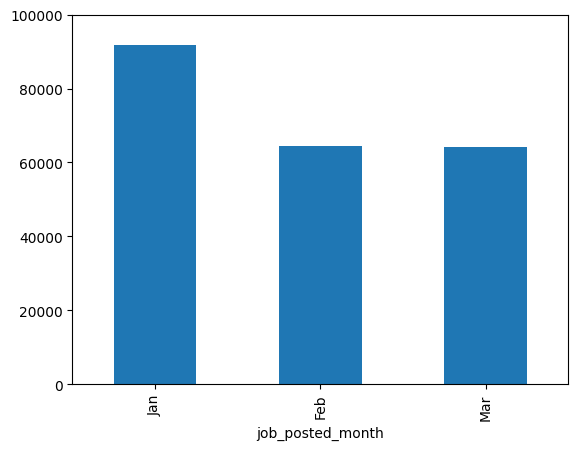

In [24]:
df_first_trimester["job_posted_month"].value_counts().plot(kind="bar", ylim=(0,100000))